# 18 — waw on SIESTA: localized Hamiltonians *without* Wannierization

Every notebook so far built its localized model by **Wannierizing** plane-wave
(QE/VASP) states — with all the care that entails: windows, frozen manifolds,
projection gauges, symmetry adaptation.  A **numerical-atomic-orbital (NAO)**
code skips that step entirely: SIESTA's Hamiltonian *is already* a localized
real-space $H(\mathbf R)$.  The one structural difference is that NAOs are
**non-orthogonal** — the band problem is $H(k)\psi = \epsilon S(k)\psi$ — so
`waw.interfaces.siesta` **Löwdin-orthogonalizes** on a uniform k-mesh,
$H_\perp(k) = S^{-1/2} H S^{-1/2}$, and Fourier-transforms to the same
Wigner–Seitz $R$-set the Wannier route uses.  The result is a standard waw
`HamiltonianR`, exact on its mesh, interpolating in between.

**What carries over unchanged** (everything that needs only $H(\mathbf R)$):
band interpolation, DOS, Fermi surfaces, surface Green functions, and — the
showcase here — the LKAG **exchange couplings** and **magnon spectra**.  A
collinear run gives the two spin channels in the *same orbital basis by
construction*, so none of the projection-gauge care of notebook 17 is needed,
and the atomic basis is symmetry-adapted for free.  For SOC runs the spin
operator is **exact** (spin lives purely on the spinor index after Löwdin).

**What does not**: Berry-curvature-class quantities (AHC/SHC/orbital
moments/SAC) need position matrix elements $\langle\phi|\mathbf r|\phi'\rangle$
that NAO codes don't export — deliberately unavailable rather than silently
approximated.

Three practical traps, all documented in the module: (i) SIESTA's saved
Hamiltonian (HSX) stores $H - E_F S$, so the loaded model's **Fermi level is
exactly 0** (the `.EIG` header is a different reference); (ii) the Löwdin
$H(\mathbf R)$ is longer-ranged than the bare NAO $H$ — converge the
orthogonalization mesh; (iii) the high NAO *virtual* states (>10 eV) are
basis-tail artifacts and never interpolate well, in any NAO code.

In [1]:
import os, sys, re, pathlib
import numpy as np
import matplotlib.pyplot as plt
import torch

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
waw.set_num_threads(16)
from ase.build import bulk
from waw.interfaces import siesta as sst
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.analysis.exchange import heisenberg_exchange
from waw.analysis.magnon import magnon_bands
from waw.units import HARTREE_TO_EV

W = REPO / 'workflows' / 'notebooks' / 'runs' / 'fe_siesta'
W.mkdir(exist_ok=True)
fe = bulk('Fe', 'bcc', a=2.8699)
cell = fe.get_cell()[:]

fdf = sst.write_fdf(W / 'fe.fdf', fe, label='fe',
                    pseudo_dir=REPO / 'workflows' / 'pseudos' / 'psml',
                    kgrid=(12, 12, 12), spin='polarized', basis='DZP',
                    initial_moments={0: 2.5})
sst.run_siesta(fdf, ncores=16)   # cached: skips if fe.out says completed
H = sst.load_hamiltonian(W / 'fe.fdf')
print('spin:', H.spin, '  NAOs:', H.no)
print('orbitals:', ', '.join(o.name() for o in H.geometry.atoms[0].orbitals))
mom = [float(x) for x in
       [l for l in (W / 'fe.out').read_text().splitlines() if 'spin moment' in l][-1]
       .split('{')[-1].replace('}', ' ').split()][:3]
print(f'SIESTA spin moment: {mom[2]:.4f} mu_B')

spin: Spin{polarized}   NAOs: 19
orbitals: 3sZ1, 4sZ1, 4sZ2, 3pyZ1, 3pzZ1, 3pxZ1, 4pyZ1, 4pzZ1, 4pxZ1, 3dxyZ1, 3dyzZ1, 3dz2Z1, 3dxzZ1, 3dx2-y2Z1, 3dxyZ2, 3dyzZ2, 3dz2Z2, 3dxzZ2, 3dx2-y2Z2
SIESTA spin moment: 2.3106 mu_B


### 1. Validation: the Löwdin model against SIESTA's own eigenvalues

Exact on the orthogonalization mesh by construction; between mesh points it
interpolates like a Wannier model of the same size.  The physically relevant
window (here up to $E_F+2$ eV) converges rapidly with the mesh; the high
virtual tail does not (and should not be used).

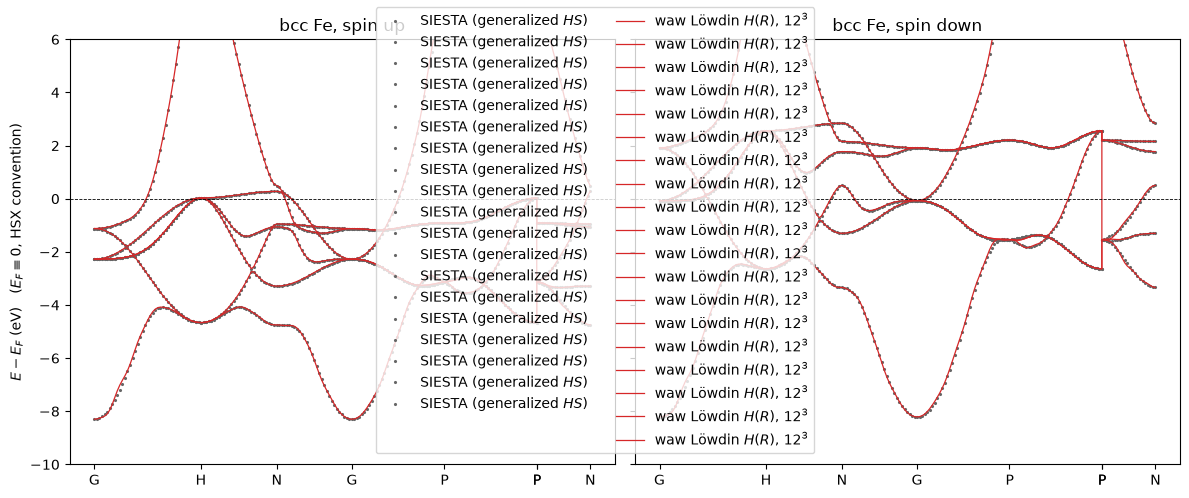

off-mesh interpolation error, bands up to E_F+2 eV:


  8^3:  155.16 meV


  12^3:   35.25 meV


  16^3:   12.63 meV


In [2]:
bp = band_path(fe, npoints=200)
x, xt, xl = bp.get_linear_kpoint_axis()

hr12 = {sp: sst.lowdin_hamiltonian(H, (12, 12, 12), spin=sp) for sp in (0, 1)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, sp in zip(axes, (0, 1)):
    e_sisl = np.array([H.eigh(k, spin=sp) for k in bp.kpts])
    e_waw = band_eigensystem(hr12[sp], bp.kpts)[0] * HARTREE_TO_EV
    ax.plot(x, e_sisl, '.', ms=2.5, color='0.4',
            label='SIESTA (generalized $HS$)' if sp == 0 else None)
    ax.plot(x, e_waw, '-', lw=0.9, color='C3',
            label='waw Löwdin $H(R)$, $12^3$' if sp == 0 else None)
    ax.set_xticks(xt); ax.set_xticklabels(xl); ax.set_ylim(-10, 6)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_title(f'bcc Fe, spin {"up" if sp == 0 else "down"}')
axes[0].set_ylabel(r'$E - E_F$ (eV)   ($E_F \equiv 0$, HSX convention)')
fig.legend(loc='upper center', ncol=2)
plt.tight_layout(); plt.show()

off = np.array([[0.1, 0.07, 0.03], [0.31, 0.11, 0.47], [0.05, 0.05, 0.05]])
e_ref = np.array([H.eigh(k, spin=0) for k in off])
print('off-mesh interpolation error, bands up to E_F+2 eV:')
for n in (8, 12, 16):
    hr = sst.lowdin_hamiltonian(H, (n, n, n), spin=0)
    e_w = band_eigensystem(hr, off)[0] * HARTREE_TO_EV
    m = e_ref < 2.0
    print(f'  {n}^3: {np.abs(e_w - e_ref)[m].max() * 1e3:7.2f} meV')

### 2. Exchange couplings with zero gauge care

Notebook 17 needed a projection gauge (`n_iter=0`), full-manifold freezing and
window craft to make the two Wannier spin channels comparable.  Here the two
channels share the atomic basis *by construction* and the basis is
symmetry-adapted for free: the $J_1$ spread over the 8 bcc neighbours is
$\sim$0.02 meV with no tricks.  (GF k-mesh = the Löwdin mesh, so the
eigensystem entering the Green's functions is exact.)

In [3]:
n = 12
g = np.meshgrid(*[np.arange(n)] * 3, indexing='ij')
kpts = np.stack([v.ravel() for v in g], axis=1) / n
Rbox = np.array([(i, j, k) for i in range(-4, 5) for j in range(-4, 5)
                 for k in range(-4, 5) if (i, j, k) != (0, 0, 0)])
Rl = Rbox[np.linalg.norm(Rbox @ cell, axis=1) <= 8.0]

D_BLOCK = [i for i, o in enumerate(H.geometry.atoms[0].orbitals) if '3d' in o.name()]
res_d = heisenberg_exchange(hr12[0], hr12[1], kpts, 0.0, [D_BLOCK], Rl, nz=100)
res_a = heisenberg_exchange(hr12[0], hr12[1], kpts, 0.0, [list(range(H.no))], Rl, nz=100)

def shells(res, label):
    sh = {}
    for R in Rl:
        d_ = round(float(np.linalg.norm(np.array(R) @ cell)), 3)
        sh.setdefault(d_, []).append(res.J[(tuple(R), 0, 0)] * HARTREE_TO_EV * 1e3)
    row = '  '.join(f'J{i+1}={np.mean(js):7.3f} (spr {np.ptp(js):.3f})'
                    for i, (d_, js) in enumerate(sorted(sh.items())[:3]))
    print(f'{label:28s} m={res.magmoms[0]:+.3f}  {row}')
    return sh

sh_d = shells(res_d, f'native, d block {D_BLOCK}')
sh_a = shells(res_a, 'native, all 19 NAOs')
print()
print('references:')
print('  TB2J siesta2J (non-orthogonal LKAG, all orbitals): J1= 11.38  J2= 14.77  J3= -0.50')
print('  notebook 17 (QE + Wannier route, PseudoDojo d-block): J1=  7.1   J2= 10.4')
print('  -> J2 > J1 with a semicore Fe pseudo, in BOTH codes and BOTH routes;')
print('     the official-TB2J-example pseudo (no semicore) inverts it (nb17).')

native, d block [9, 10, 11, 12, 13, 14, 15, 16, 17, 18] m=+2.480  J1=  7.733 (spr 0.025)  J2= 14.460 (spr 0.000)  J3= -0.253 (spr 0.003)
native, all 19 NAOs          m=+2.312  J1=  3.538 (spr 0.024)  J2= 11.188 (spr 0.000)  J3= -0.410 (spr 0.003)

references:
  TB2J siesta2J (non-orthogonal LKAG, all orbitals): J1= 11.38  J2= 14.77  J3= -0.50
  notebook 17 (QE + Wannier route, PseudoDojo d-block): J1=  7.1   J2= 10.4
  -> J2 > J1 with a semicore Fe pseudo, in BOTH codes and BOTH routes;
     the official-TB2J-example pseudo (no semicore) inverts it (nb17).


The Löwdin-orthogonal and TB2J's non-orthogonal LKAG are *different effective-J
definitions* at finite exchange splitting — **proven, not just argued**
(`analysis.exchange.heisenberg_exchange_nonortho`, the same LKAG with
$G=(zS-H)^{-1}$ in the raw NAO basis): on this exact data it moves the
all-orbital $J_1$ from 3.5 to 9.8 meV, and with TB2J's own conventions
(its Gaussian-occupation $E_F$, band truncation) reproduces `siesta2J` to
<1.5 meV per shell (`tests/test_analysis_exchange.py::
test_siesta_nonortho_vs_siesta2j`).  The residual is Fermi-level placement:
metallic LKAG here has $dJ_1/dE_F \approx 155$ meV per eV, so $\pm10$ meV of
$E_F$ moves $J_1$ by $\pm1.5$ meV — compare like with like.  The cross-code,
cross-route teaching stands: the $J_2>J_1$ ordering follows the
**pseudopotential family** (semicore PseudoDojo here and in the QE route; the
example's semicore-free pseudo restores $J_1>J_2$), not the code or the
localization method.

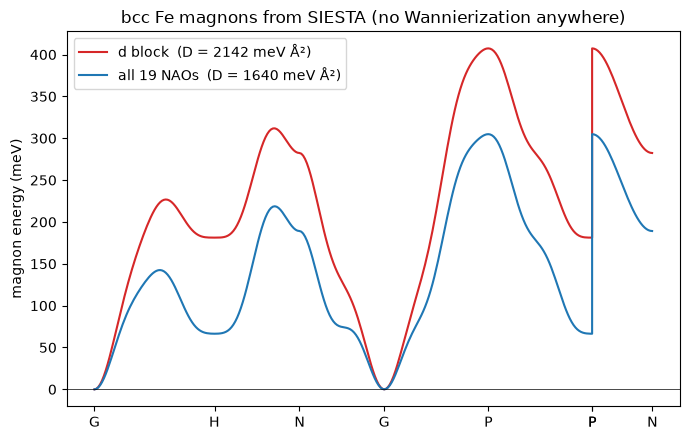

In [4]:
bp_m = band_path(fe, npoints=300)
xm, xmt, xml = bp_m.get_linear_kpoint_axis()
fig, ax = plt.subplots(figsize=(7, 4.5))
for res, lab, c in ((res_d, 'd block', 'C3'), (res_a, 'all 19 NAOs', 'C0')):
    D = sum(v * np.linalg.norm(np.array(R) @ cell)**2
            for (R, i, j), v in res.J.items()) * HARTREE_TO_EV * 1e3
    w = magnon_bands(res.J, np.array([res.magmoms[0]]), bp_m.kpts) * HARTREE_TO_EV * 1e3
    ax.plot(xm, w[:, 0], color=c, label=f'{lab}  (D = {D:.0f} meV Å²)')
ax.set_xticks(xmt); ax.set_xticklabels(xml); ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('magnon energy (meV)'); ax.legend()
ax.set_title('bcc Fe magnons from SIESTA (no Wannierization anywhere)')
plt.tight_layout(); plt.show()

**Takeaway.**  A DFT code with a localized basis plugs into waw with a single
Löwdin step: `write_fdf → run_siesta → load_hamiltonian → lowdin_hamiltonian`
gives a `HamiltonianR` that every $H$-only analysis consumes unchanged — here
DFT → exchange → magnons for bcc Fe in ~2 minutes of SIESTA time, with
symmetry-adapted couplings and none of the Wannierization craft of notebooks
14–17.  The same loader handles SOC runs (exact spinor spin operator from the
overlap).  Berry-curvature quantities remain Wannier-route territory until
NAO position matrix elements are wired in.  `pyscf` (Gaussian PBC) could enter
by the same door: anything that provides $H(k)/S(k)$ on a mesh is one Löwdin
away from a waw model.